# Why Jupyterlab

Jupyter notebooks are great for developing data products, whether it's data analysis, data pipelines, or (classical) ML models. The format enables an interactive, iterative workflow where you can incrementally execute snippets of code and immediately seeing results inline. This makes it very easy to incrementally build your analyis and/or data pipeline and then develop that code into reusable and importable functions or classes.

In this post, I'll show:
* an example of this Jupyter-enabled workflow (both the EDA workflow and the tooling development workflow), and
* how I set up `jupyterlab` (including my solutions to `jupyterlab`'s few annoying quirks)

# Example Workflow

I'll break this down into two parts, the EDA (Exploratory Data Analysis) workflow, and then the Development workflow (which will build upon the EDA workflow).

## Exploratory Data Analysis workflow

Thanks to python's robust data science/analysis/engineering ecosystem, you can load a dataset into memory in one line of code and then iteratvely explore loaded datasets, as shown in the **cells** below.

In [1]:
#| code-fold: true
#| code-summary: Formatting and Imports
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

pd.options.display.max_columns = None
pd.options.display.max_colwidth = 150

In [2]:
#| code-fold: show
#| code-summary: Loading data
chicago_boundary = gpd.read_file("https://data.cityofchicago.org/api/geospatial/qqq8-j68g?method=export&format=GeoJSON")
chicago_park_events = gpd.read_file("https://data.cityofchicago.org/api/geospatial/tn7v-6rnw?method=export&format=GeoJSON")

print(chicago_park_events.shape)
display(chicago_park_events.head(2))

(7597, 28)


,start_date,latitude,zip,description,registration_date,location_notes,restrictions,activity_type,age_range,season,longitude,registration_link,activity_id,end_date,image_link,location_facility,address,category,information_link,title,event_cancelled,type,movie_title,movie_rating,zone,date_notes,fee,geometry
0,2026-01-07 07:00:00,None,None,"January 7, 2026 to March 4, 2026",2025-12-10 15:00:00,None,None,Open,All Ages,None,None,None,567134,2026-03-04 08:00:00,None,None,None,Sports - Skating,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/567134,Ice Skating - Freestyle Ice (Main Rink) at McFetridge,None,Program,None,None,None,"From January 7, 2026 to March 4, 2026 Each Wednesday from 7am to 8am",72,None
1,2026-01-05 18:50:00,None,None,"January 5, 2026 to February 23, 2026",2025-12-10 15:00:00,None,None,Instruction,All Ages,None,None,None,567122,2026-02-23 19:30:00,None,None,None,Sports - Skating,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/567122,Ice Skating - Freestyle 5 at McFetridge,None,Program,None,None,None,"From January 5, 2026 to February 23, 2026 Each Monday from 6:50pm to 7:30pm",127,None


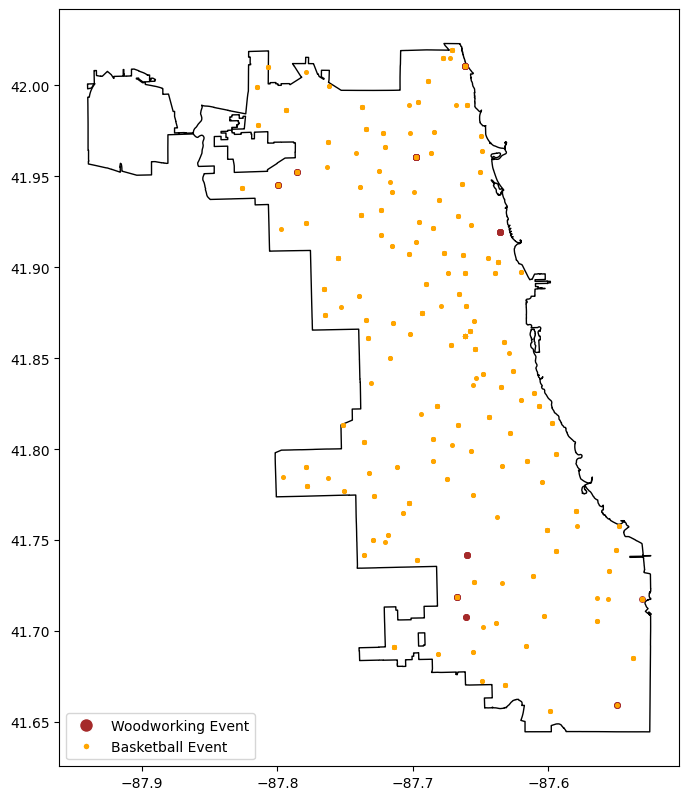

In [3]:
#| code-fold: show
#| code-summary: Exploring data
woodworking_events = chicago_park_events.loc[chicago_park_events["category"] == "Woodworking"]
basketball_events = chicago_park_events.loc[chicago_park_events["category"] == "Sports - Basketball"]

fig, ax = plt.subplots(figsize=(8,10))
ax = chicago_boundary.plot(facecolor="none", ax=ax)
ax = woodworking_events.plot(markersize=15, ax=ax, color="brown")
ax = basketball_events.plot(markersize=7, ax=ax, color="orange")
legend_elements = [
    Line2D([0], [0], marker="o", color='w', markerfacecolor="brown", markersize=10, label="Woodworking Event"),
    Line2D([0], [0], marker=".", color='w', markerfacecolor="orange", markersize=10, label="Basketball Event"),
]
_ = ax.legend(handles=legend_elements, loc="lower left")

## Development Workflow

Above, we loaded some data and visualized an aspect of two specific subsets of the data. It's not too easy to reuse or adapt to explore other subsets, but the notebook format makes it easy to iteratively refactor those experiments into something reusable that's also much easier to version-control.

Below, I've refactored the above experiments into a reusable bit of code that retrieves the data and provides methods to inspect counts of Chicago Park Dept events and map out events.

In [4]:
#| code-fold: show
#| code-summary: Encapsulating Functionality
from typing import Optional

class ChicagoParkEventExplorer:
    def __init__(
        self,
        chicago_boundary: Optional[gpd.GeoDataFrame] = None,
        chicago_park_events: Optional[gpd.GeoDataFrame] = None
    ) -> None:
        self.load_chicago_boundary(chicago_boundary)
        self.load_chicago_park_events(chicago_park_events)

    def load_chicago_boundary(self, df: Optional[gpd.GeoDataFrame] = None) -> None:
        if df is not None:
            self.chicago_boundary = df.copy()
        else:
            self.chicago_boundary = gpd.read_file(
                "https://data.cityofchicago.org/api/geospatial/qqq8-j68g?"
                "method=export&format=GeoJSON"
            )
            self.chicago_boundary

    def load_chicago_park_events(self, df: Optional[gpd.GeoDataFrame] = None) -> None:
        if df is not None:
            self.chicago_park_events = df.copy()
        else:
            print("Getting fresh Chicago Parks Dept Events data.")
            self.chicago_park_events = gpd.read_file(
                "https://data.cityofchicago.org/api/geospatial/tn7v-6rnw?"
                "method=export&format=GeoJSON"
            )
        col_order = [
            "activity_id", "title", "description", "category", "activity_type",
            "start_date", "end_date", "registration_date", "date_notes", "age_range",
            "location_facility", "address", "zip", "fee", "information_link", "type",
            "movie_title", "movie_rating", "image_link", "registration_link",
            "event_cancelled", "season", "zone", "restrictions", "location_notes",
            "latitude", "longitude", "geometry"
        ]
        self.chicago_park_events = self.chicago_park_events[col_order].copy()
        self.chicago_park_events = self.chicago_park_events.convert_dtypes()

    @property
    def event_category_counts(self) -> pd.Series:
        return self.chicago_park_events["category"].value_counts(dropna=False)

    def plot_events(self, event_categories: list[str], fig_width: int = 8) -> plt.Axes:
        markers = ["o", "*", "x", "+", ".", "1", "2", "3", "4"]
        cmap = plt.get_cmap("tab10", len(markers))
        colors = [cmap(i) for i in range(len(markers))]
        if len(event_categories) > len(markers):
            print(f"Too many categories entered, showing the first {len(markers)}")
        fig, ax = plt.subplots(figsize=(fig_width, fig_width*1.618))
        ax = self.chicago_boundary.plot(facecolor="none", ax=ax)
        legend_elements = []
        for i, event_category in enumerate(event_categories):
            df = self.chicago_park_events.loc[
                self.chicago_park_events["category"] == event_category
            ].copy()
            ax = df.plot(
                marker=markers[i], markersize=fig_width*6, color=colors[i], ax=ax
            )
            legend_elements.append(Line2D(
                [0], [0], marker=markers[i], color="w", markerfacecolor=colors[i],
                markeredgecolor=colors[i], markersize=fig_width,
                markeredgewidth=fig_width*0.2, label=event_category
            ))
        _ = ax.legend(
            handles=legend_elements, loc="lower left", fontsize=fig_width*1.5,
            markerscale=2
        )
        return ax

event_explorer = ChicagoParkEventExplorer(chicago_boundary, chicago_park_events)
print(event_explorer.chicago_park_events.shape)
event_explorer.chicago_park_events.head(2)

(7597, 28)


,activity_id,title,description,category,activity_type,start_date,end_date,registration_date,date_notes,age_range,location_facility,address,zip,fee,information_link,type,movie_title,movie_rating,image_link,registration_link,event_cancelled,season,zone,restrictions,location_notes,latitude,longitude,geometry
0,567134,Ice Skating - Freestyle Ice (Main Rink) at McFetridge,"January 7, 2026 to March 4, 2026",Sports - Skating,Open,2026-01-07 07:00:00,2026-03-04 08:00:00,2025-12-10 15:00:00,"From January 7, 2026 to March 4, 2026 Each Wednesday from 7am to 8am",All Ages,<NA>,<NA>,<NA>,72,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/567134,Program,None,None,<NA>,<NA>,<NA>,<NA>,<NA>,None,<NA>,<NA>,<NA>,None
1,567122,Ice Skating - Freestyle 5 at McFetridge,"January 5, 2026 to February 23, 2026",Sports - Skating,Instruction,2026-01-05 18:50:00,2026-02-23 19:30:00,2025-12-10 15:00:00,"From January 5, 2026 to February 23, 2026 Each Monday from 6:50pm to 7:30pm",All Ages,<NA>,<NA>,<NA>,127,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/567122,Program,None,None,<NA>,<NA>,<NA>,<NA>,<NA>,None,<NA>,<NA>,<NA>,None


In [5]:
#| code-fold: show
#| code-summary: Exploring Category Counts
i=30
event_explorer.event_category_counts.iloc[i: i+20]

category
Walking                                  55
Specialized                              52
Textiles                                 49
Theater                                  41
Sports - Cheerleading                    41
Painting                                 40
Drawing                                  40
Aerobics                                 36
Sports - Track &amp; Field               34
Self-Defense                             32
Sports - Archery                         30
Sports - Table Tennis                    26
Sports - Baseball                        25
Sports, Girls P.L.A.Y. Events            24
Sports - Badminton                       21
Sports - Football                        20
Sports                                   19
Out of School Programs - After School    17
Sports - Bowling                         16
Photography                              14
Name: count, dtype: Int64

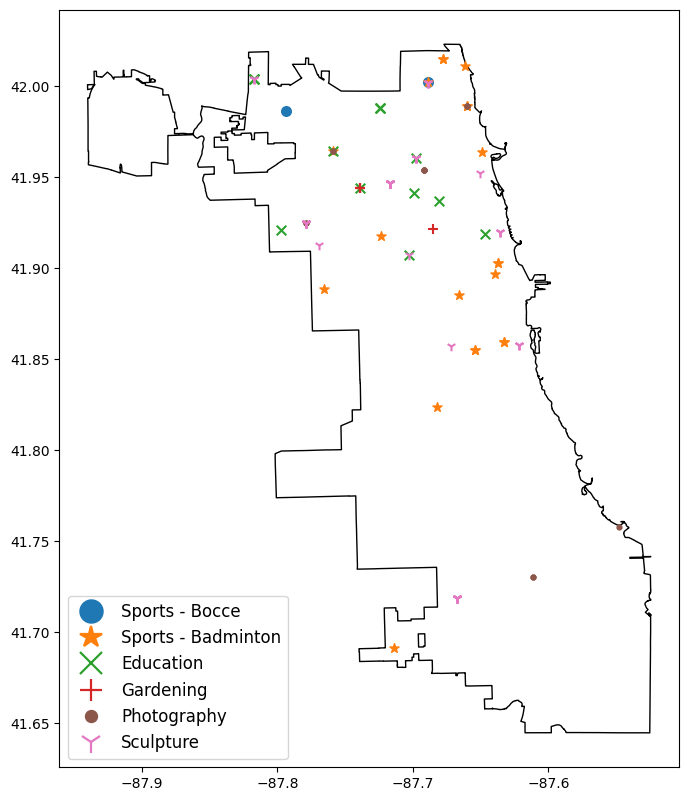

In [6]:
#| code-fold: show
#| code-summary: (nearly exclusively) North-side Events
ax = event_explorer.plot_events(
    event_categories=["Sports - Bocce", "Sports - Badminton", "Education",
                      "Gardening", "Photography", "Sculpture"],
    fig_width=8
)

There are more yoga events than I expected, and it looks like it's a common event at Chicago's beaches (which are all parkland thanks to Daniel Burnham's visionary 1909 "Plan of Chicago").

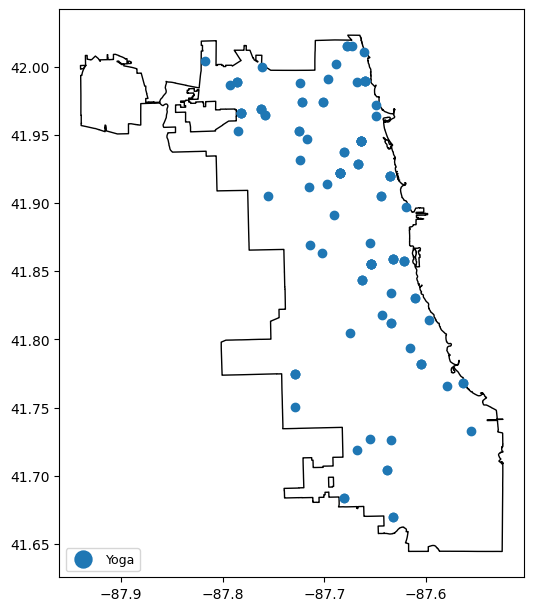

In [7]:
#| code-fold: show
#| code-summary: Yoga Events
ax = event_explorer.plot_events(
    event_categories=["Yoga"],
    fig_width=6
)

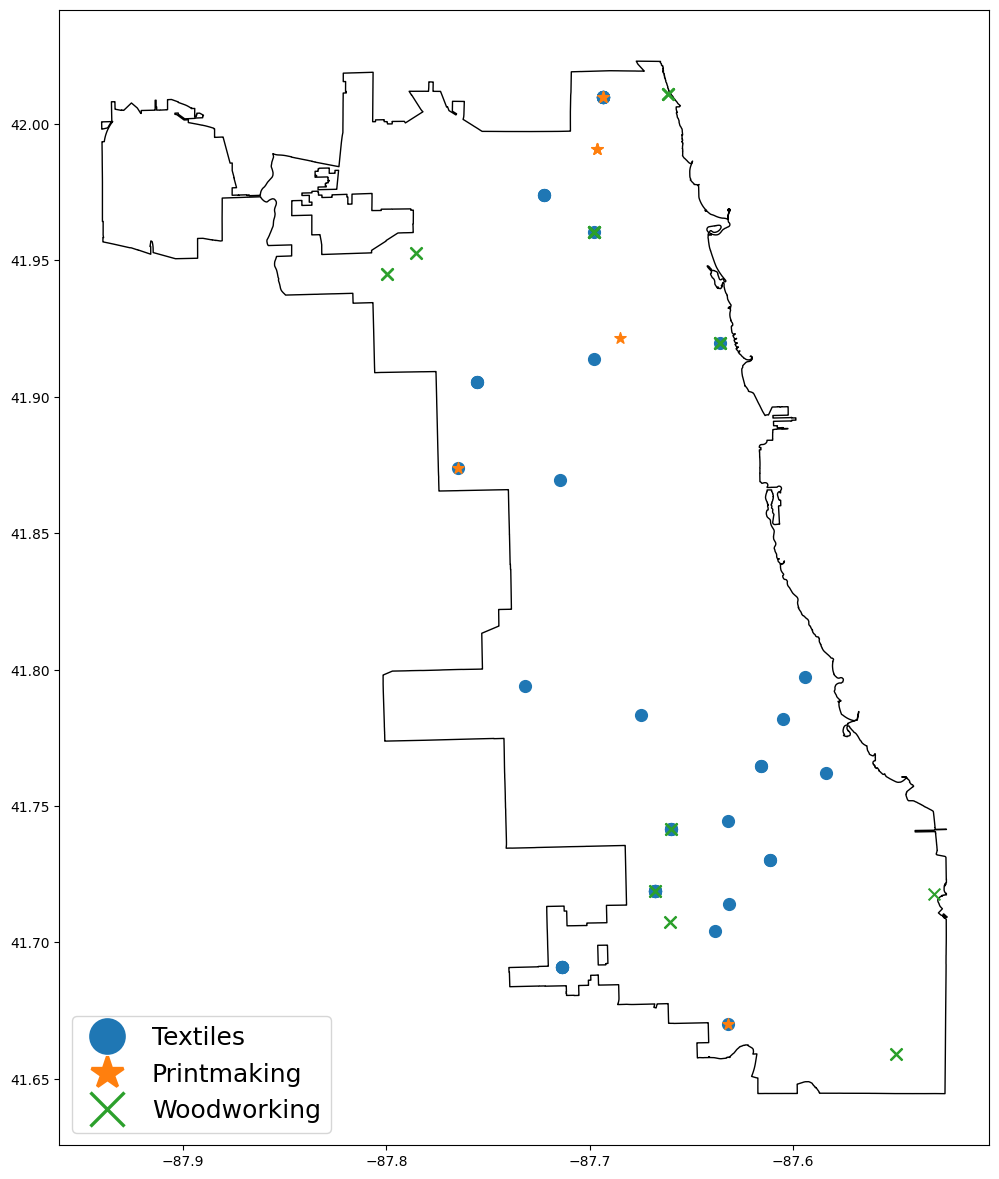

In [8]:
#| code-fold: show
#| code-summary: Crafty Events
ax = event_explorer.plot_events(
    event_categories=["Textiles", "Printmaking", "Woodworking"],
    fig_width=12
)

Hmm, that swath of textile events from Beverly to South Shore is kind of interesting. I wonder what the story behind that is (more instructors? more community interest?)

### Importablity

When our tooling is developed enough to version control, we can mode it to a `.py` file and import it into this or subsequent notebooks by adding the containing directory to the Python Path.

In [9]:
#| code-fold: show
#| code-summary: Making code importable
import sys
from pathlib import Path

module_dir = Path(".").resolve()
print(f"Directory we're adding to the python path (so we can import from it):\n  {module_dir}")
sys.path.append(str(module_dir))

Directory we're adding to the python path (so we can import from it):
  /home/matt/projects/blogs/quarto_blog/posts/020_uv_jupyterlab_setup


Jupyter notebooks default to only executing imports once, so changes made to code in a local `.py` file won't be accessible in your notebook unless you configure your notebook to automatically reload changes.

In [10]:
#| code-fold: show
#| code-summary: Making code changes automatically reload
%load_ext autoreload
%autoreload 1
%aimport developed_tools

In [11]:
#| code-fold: show
#| code-summary: Importing from our .py file
from developed_tools import ExtractedChicagoParkEventExplorer

imported_event_explorer = ExtractedChicagoParkEventExplorer()
print(imported_event_explorer.chicago_park_events.shape)
imported_event_explorer.chicago_park_events.head(2)

Getting fresh Chicago Parks Dept Events data.
(7597, 28)


,activity_id,title,description,category,activity_type,start_date,end_date,registration_date,date_notes,age_range,location_facility,address,zip,fee,information_link,type,movie_title,movie_rating,image_link,registration_link,event_cancelled,season,zone,restrictions,location_notes,latitude,longitude,geometry
0,546961,Park Kids - Fall Winter Spring at Haines School,"August 18, 2025 to June 4, 2026",After School,Activity Package,2025-08-18 14:45:00,2026-06-04 18:00:00,2025-08-05 14:00:00,"From August 18, 2025 to June 4, 2026 Each Monday,Tuesday,Wednesday,Thursday,Friday from 2:45pm to 6pm",Youth,<NA>,<NA>,<NA>,543,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/546961,Program,None,None,<NA>,<NA>,<NA>,<NA>,<NA>,None,<NA>,<NA>,<NA>,None
1,550133,Pickleball at Sauganash,"January 5, 2026 to March 9, 2026",Sports - Pickleball,Instruction,2026-01-05 15:30:00,2026-03-09 16:30:00,2025-12-08 15:00:00,"From January 5, 2026 to March 9, 2026 Each Monday from 3:30pm to 4:30pm",Youth,Sauganash Park,5861 N. Kostner Ave.,60646,21,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/550133,Program,None,None,<NA>,<NA>,<NA>,<NA>,<NA>,None,<NA>,41.9882037,-87.7372685,POINT (-87.73727 41.9882)


# Setup

I've worked through a number of different setups, but I've used this setup for two years for my general analysis and development work without any frustrations.

I use the excellent [uv python project manager](https://github.com/astral-sh/uv) to manage dependencies and run the server.

I have all of my projects in a directory `~/projects`, and I make a directory for my `jupyter` environment.

I can set up the project, install dependencies, and generate a config file via

```console
mkdir -p ~/projects/jupyter && cd ~/projects/juypyter
uv init
uv add jupyterlab geopandas matplotlib
uv run jupyter server --generate-config
```

And I can start up a server and access it via the machine I'm `ssh`-ing in from via

```console
cd ~/projects
uv --project /jupyter run jupyterlab --ip 0.0.0.0 --no-browser
```

In [12]:
#| code-fold: show
#| code-summary: Examining the ~/projects/jupyter directory
!ls -la ~/projects/jupyter

total 580
drwxrwxr-x  4 matt matt   4096 Dec  6 12:39 .
drwxrwxr-x 61 matt matt   4096 Jan 30 22:46 ..
drwxrwxr-x  7 matt matt   4096 Feb 13 12:32 .git
-rw-rw-r--  1 matt matt    109 Dec  6 12:39 .gitignore
-rw-rw-r--  1 matt matt     85 Dec  6 12:39 main.py
-rw-rw-r--  1 matt matt    498 Feb  7 18:51 pyproject.toml
-rw-rw-r--  1 matt matt      5 Dec  6 12:39 .python-version
-rw-rw-r--  1 matt matt      0 Dec  6 12:39 README.md
-rw-rw-r--  1 matt matt 561107 Feb  7 18:51 uv.lock
drwxrwxr-x  7 matt matt   4096 Jan 17 00:50 .venv


## Relocating .ipynb_checkpoints files

Jupyter notebooks default to automatically creating a hidden directory named `.ipynb_checkpoints` in whatever directory a the notebook is in, and in that directory is periodically autosaves backups of a notebook. In development workflows (where something automatically detects files through subdirectories), this can be particularly annoying.

Fortunately, we can reconfigure that. In the `~/.jupyter/jupyter_server_config.py` file that we generated above (via the `uv run jupyter server --generate-config` command), add these lines around the `c = get_config()` line to create a directory to shunt checkpoint files to and to actually route checkpoint files there.

In [13]:
#| code-fold: show
#| code-summary: Examining the code one must add to their jupyter server config to relocate .ipynb_checkpoints files
!cat ~/.jupyter/jupyter_server_config.py | head -n 12

from pathlib import Path

# Configuration file for jupyter-server.

CHECKPOINT_DIR = Path("~").joinpath("projects", ".temp", ".jupyter", ".checkpoints").expanduser()
if not CHECKPOINT_DIR.is_dir():
    CHECKPOINT_DIR.mkdir(parents=True)

c = get_config()  #noqa

c.FileCheckpoints.checkpoint_dir = str(CHECKPOINT_DIR)



## Showing hidden files

The other annoying `jupyter` default is that hidden files (like `.env` files) are not displayed in the file browser. To correct this, uncomment the `...ContentsManager.allow_hidden` lines and make sure they're set to `True`.

In [14]:
#| code-fold: show
#| code-summary: Examining the configs that have to be changed to show hidden files in the File Browser
!grep -n "c.*allow_hidden" ~/.jupyter/jupyter_server_config.py

1048:c.ContentsManager.allow_hidden = True
1175:c.FileContentsManager.allow_hidden = True
1263:c.AsyncContentsManager.allow_hidden = True
1339:c.AsyncFileContentsManager.allow_hidden = True


# Summary

That's basically all it takes to get up and running. After the above setup, you only have to run this (then copy the displayed URL to a browser).

```console
cd ~/projects
uv --project /jupyter run jupyterlab --ip 0.0.0.0 --no-browser
```

And to install new dependencies, just use this pattern. It will be accessible in the default `Python 3 (ipykernel)` notebook option.

```console
cd ~/projects/jupyter
uv add <whatever dependencies you need>
```